In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import plotly.express as px
import plotly.graph_objects as go

# EDA

In [24]:
DATA = '../data/VDS2526_Madrid'

# Load station metadata
stations = pd.read_csv(f'{DATA}/stations.csv')

# Load and combine all yearly measurement files
all_files = sorted(glob.glob(f'{DATA}/madrid_*.csv'))
measurements = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

# Parse date and extract time components
measurements['date'] = pd.to_datetime(measurements['date'])
measurements['year'] = measurements['date'].dt.year
measurements['month'] = measurements['date'].dt.month
measurements['hour'] = measurements['date'].dt.hour

# Merge station metadata into measurements
measurements = measurements.merge(stations, left_on='station', right_on='id', how='left')

print(f"Total rows: {measurements.shape[0]}")
print(f"Columns: {measurements.columns.tolist()}")

Total rows: 3808224
Columns: ['date', 'BEN', 'CO', 'EBE', 'MXY', 'NMHC', 'NO_2', 'NOx', 'OXY', 'O_3', 'PM10', 'PXY', 'SO_2', 'TCH', 'TOL', 'station', 'PM25', 'NO', 'CH4', 'year', 'month', 'hour', 'id', 'name', 'address', 'lon', 'lat', 'elevation']


In [25]:
measurements.head()

,date,BEN,CO,EBE,MXY,NMHC,NO_2,NOx,OXY,O_3,...,CH4,year,month,hour,id,name,address,lon,lat,elevation
0,2001-08-01 01:00:00,NaN,0.37,NaN,NaN,NaN,58.400002,87.150002,NaN,34.529999,...,NaN,2001,8,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2001-08-01 01:00:00,1.5,0.34,1.49,4.1,0.07,56.250000,75.169998,2.11,42.160000,...,NaN,2001,8,1,28079035.0,Pza. del Carmen,Plaza del Carmen esq. Tres Cruces.,-3.703172,40.419208,659.0
2,2001-08-01 01:00:00,NaN,0.28,NaN,NaN,NaN,50.660000,61.380001,NaN,46.310001,...,NaN,2001,8,1,NaN,NaN,NaN,NaN,NaN,NaN
3,2001-08-01 01:00:00,NaN,0.47,NaN,NaN,NaN,69.790001,73.449997,NaN,40.650002,...,NaN,2001,8,1,28079004.0,Pza. de España,Plaza de España,-3.712247,40.423853,635.0
4,2001-08-01 01:00:00,NaN,0.39,NaN,NaN,NaN,22.830000,24.799999,NaN,66.309998,...,NaN,2001,8,1,28079039.0,Barrio del Pilar,Avd. Betanzos esq. C/ Monforte de Lemos,-3.711542,40.478228,674.0


In [26]:
#check amount of data across the years
print(measurements['year'].value_counts().sort_index())

year
2001    217847
2002    217296
2003    243981
2004    245496
2005    237002
2006    230569
2007    225119
2008    226393
2009    215693
2010    209443
2011    209929
2012    210720
2013    209880
2014    210024
2015    210096
2016    209496
2017    210120
2018     69120
Name: count, dtype: int64


In [27]:
#exclude 2018 (only 3 months worth of data)
df_full = measurements[measurements['year'] <= 2017]

In [28]:
# Missing values as percentages
ALL_POLLUTANTS = ['BEN', 'CO', 'EBE', 'MXY', 'NMHC', 'NO_2', 'NOx',
                  'OXY', 'O_3', 'PM10', 'PXY', 'SO_2', 'TCH', 'TOL',
                  'PM25', 'NO', 'CH4']

missing = (df_full[ALL_POLLUTANTS].isnull().sum() / len(df_full) * 100).round(1)
print(missing.sort_values())

NO_2     0.6
O_3     21.1
PM10    24.5
SO_2    26.5
CO      29.9
NOx     38.3
NO      60.9
NMHC    71.2
TCH     71.2
BEN     72.6
TOL     72.7
EBE     73.7
PM25    78.7
MXY     91.6
OXY     91.6
PXY     91.6
CH4     99.8
dtype: float64


In [29]:
# KEY_POLLUTANTS
# Select only pollutants with at least 70% data availability
THRESHOLD = 70
KEY_POLLUTANTS = missing[missing <= 30].index.tolist()

print(f"Pollutants with >= {THRESHOLD}% availability:")
print(KEY_POLLUTANTS)

stats = df_full[KEY_POLLUTANTS].describe().round(2)
print(stats)

Pollutants with >= 70% availability:
['CO', 'NO_2', 'O_3', 'PM10', 'SO_2']


               CO        NO_2         O_3        PM10        SO_2
count  2622404.00  3718200.00  2951669.00  2824332.00  2747364.00
mean         0.55       50.69       39.76       29.14       10.71
std          0.54       34.62       30.41       26.02        9.14
min          0.00        0.00        0.00        0.00        0.00
25%          0.26       24.00       12.65       11.75        5.90
50%          0.40       44.32       34.66       21.75        8.20
75%          0.65       69.90       59.74       38.00       12.36
max         18.04      628.60      236.00      695.00      199.10


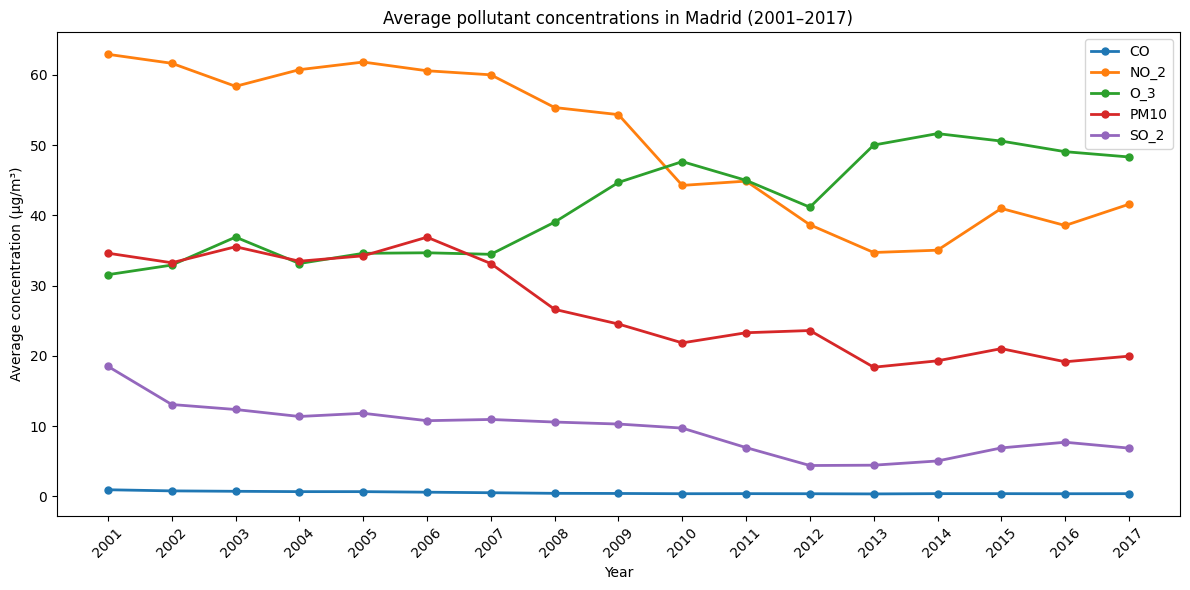

In [30]:
yearly_avg = df_full.groupby('year')[KEY_POLLUTANTS].mean()

fig, ax = plt.subplots(figsize=(12, 6))

for pollutant in KEY_POLLUTANTS:
    ax.plot(yearly_avg.index, yearly_avg[pollutant],
            marker='o', linewidth=2, markersize=5, label=pollutant)

ax.set_xlabel('Year')
ax.set_ylabel('Average concentration (µg/m³)')
ax.set_title('Average pollutant concentrations in Madrid (2001–2017)')
ax.set_xticks(yearly_avg.index)
ax.set_xticklabels(yearly_avg.index, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Question 1